# Generation and post-analysis in a real dataset 

#### Associated publication
Reference: https://www.nejm.org/doi/full/10.1056/NEJM199709113371101

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tableone import TableOne
import torch
from sksurv.nonparametric import kaplan_meier_estimator
import os
import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization, metrics

module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

from synthcity.metrics.plots import plot_tsne
from synthcity.metrics.eval import Metrics
from synthcity.metrics.scores import ScoreEvaluator
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader
from synthcity.utils.reproducibility import clear_cache, enable_reproducible_results

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [2]:
dataset_name = "ACTG320"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
miss_file = ""
true_miss_file = None

### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [3]:
control_fnames = ['time', 'censor'] + pd.read_csv(feat_types_file_control)["name"].to_list()[1:]
control = pd.read_csv(data_file_control, header=None, names=control_fnames)
print(control.head())

   time  censor  strat2  sex  raceth  ivdrug  karnof    cd4  priorzdv  age
0   189       0       1    0       1       0     100  169.0      39.0   34
1   287       0       1    1       2       0      90  149.5      15.0   34
2   199       0       1    0       1       0      90   46.0      53.0   48
3   270       0       1    0       2       0     100   54.5       6.0   51
4   276       0       1    0       1       0     100   95.0       7.0   34


In [4]:
# Load and transform control data
data_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _ = data_processing.read_data(data_file_control, 
                                                                                                             feat_types_file_control, 
                                                                                                             miss_file, true_miss_file)

In [5]:
# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _, dict_cat_map_control = data_processing.read_data(data_file_control, feat_types_file_control, miss_file, true_miss_file,
                                                                                                                                         return_cat_mapping=True)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _, dict_cat_map_treated = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file,
                                                                                      return_cat_mapping=True)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

In [6]:
continuous_variables_control = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical_variables_control = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]

In [7]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update the data
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

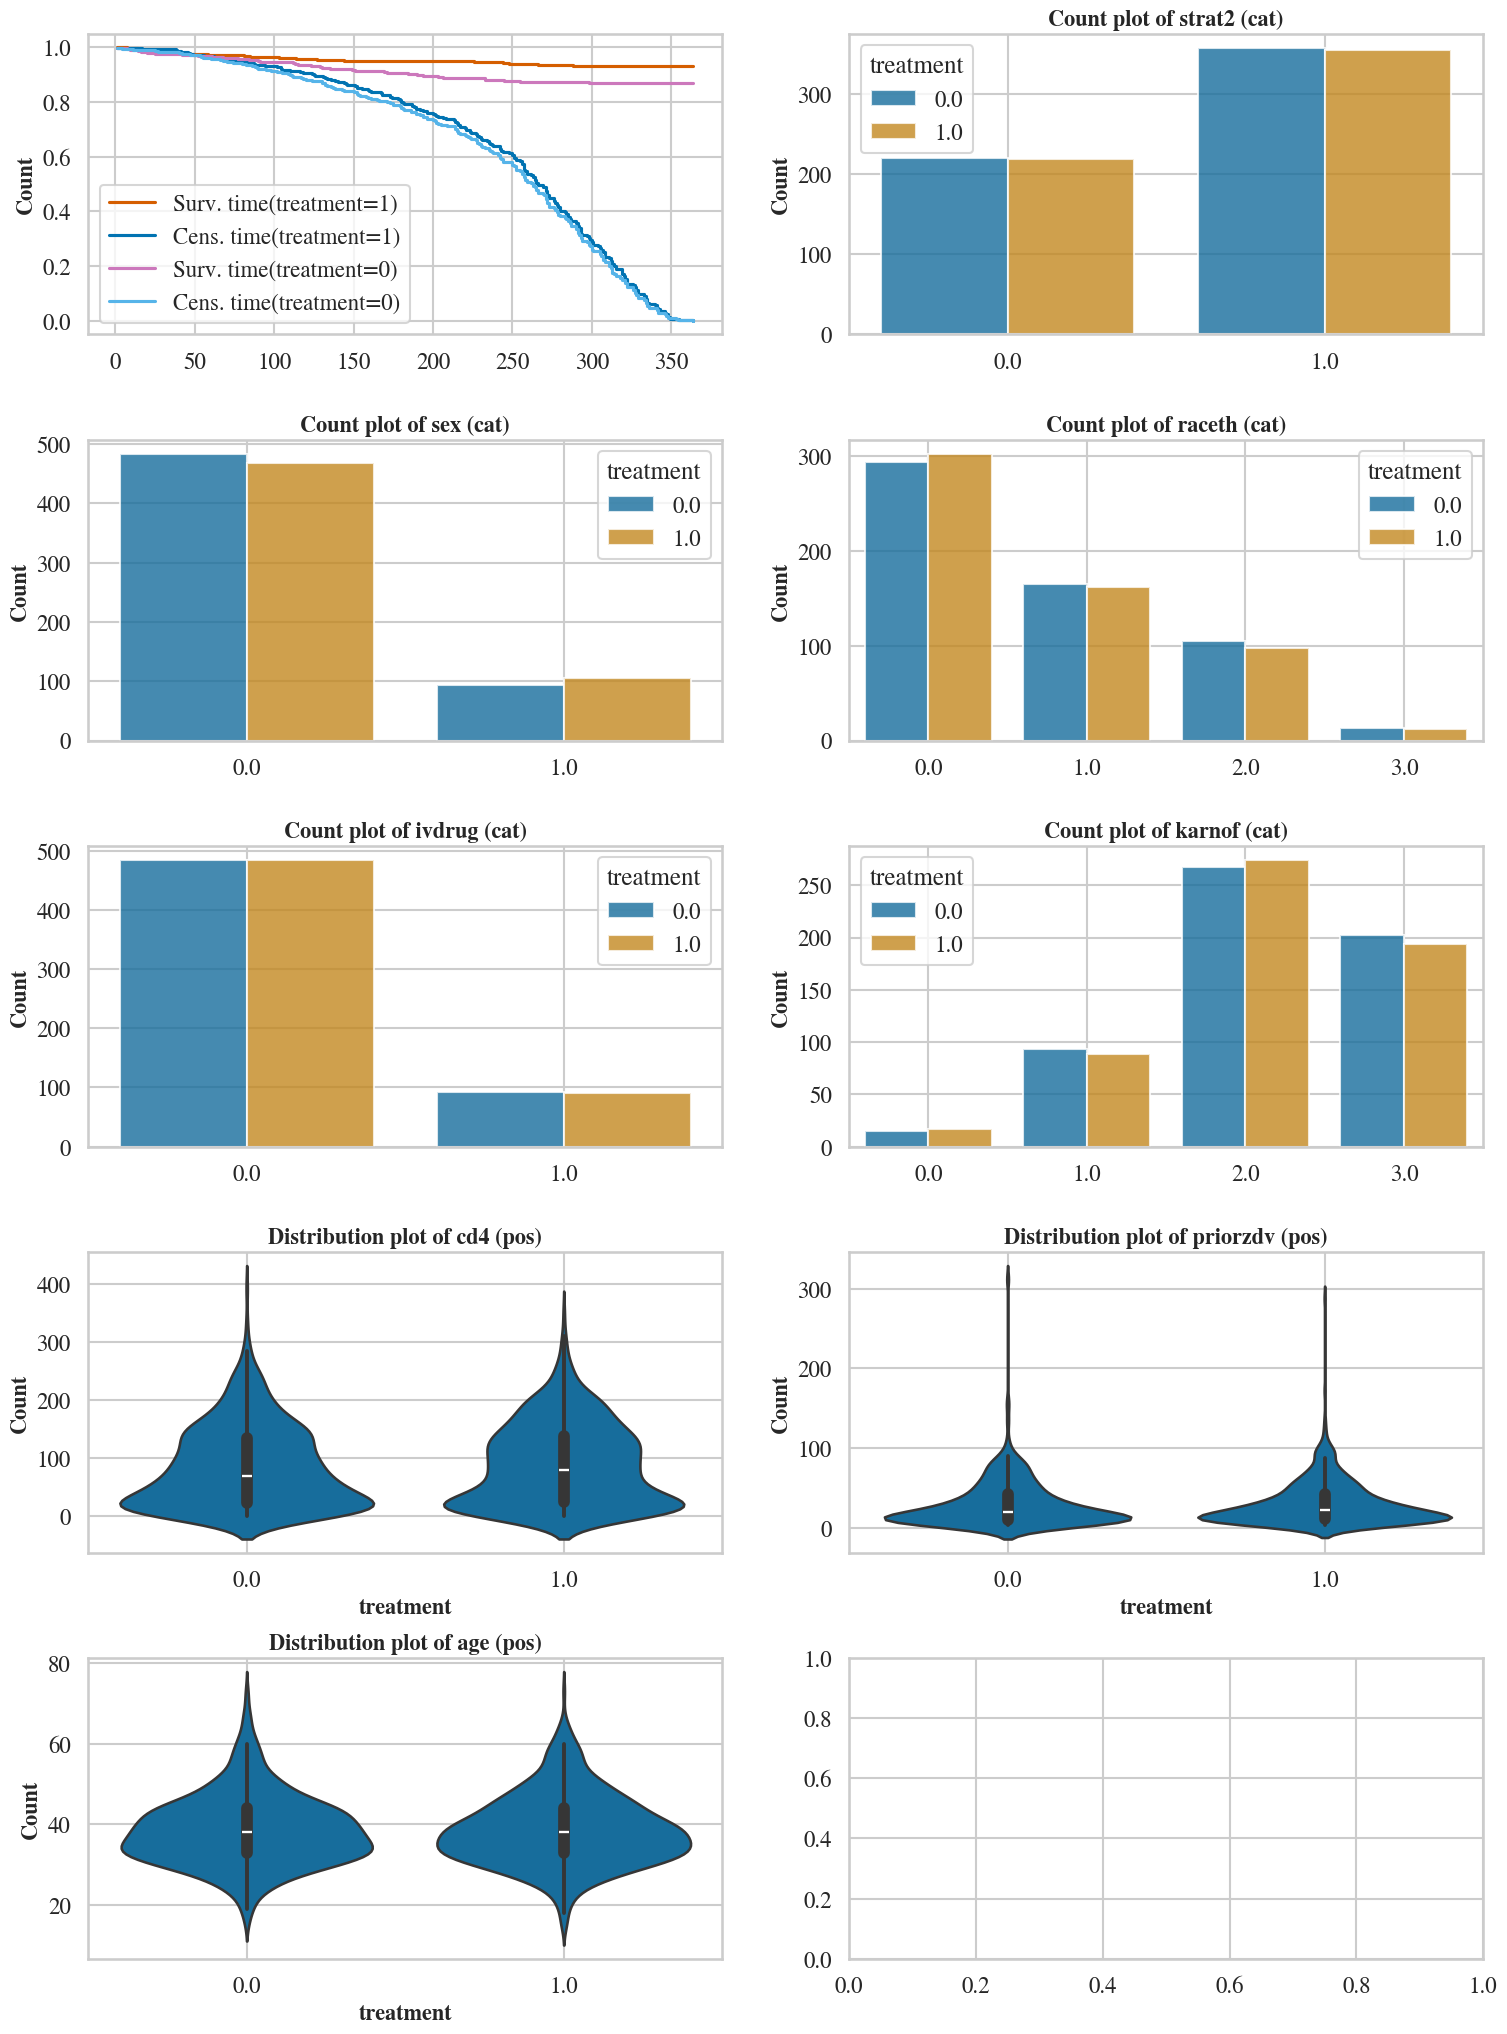

In [8]:
# TODO: Refactor
feat_types_dict_all = feat_types_dict.copy()
feat_types_dict_all.append({'name': 'treatment', 'type': 'cat', 'dim': '1', 'nclass': '2'})
visualization.plot_data(df_init.to_numpy(), feat_types_dict_all, feat_comparison_name='treatment')

In [9]:
continuous = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]

In [10]:
from metrics import tableone_tests

surv_table1, _, _, _ = tableone_tests(df_init, groupby = 'treatment', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

table1 = TableOne(df_init, groupby = 'treatment', categorical=categorical, continuous=continuous, nonnormal=continuous, pval=True)
print(table1)
 

Log-rank test p-value: 0.001
                             Grouped by treatment                                                                 
                                          Missing            Overall                  0                  1 P-Value
n                                                               1151                577                574        
strat2, n (%)            0.0                              439 (38.1)         220 (38.1)         219 (38.2)   1.000
                         1.0                              712 (61.9)         357 (61.9)         355 (61.8)        
sex, n (%)               0.0                              951 (82.6)         483 (83.7)         468 (81.5)   0.370
                         1.0                              200 (17.4)          94 (16.3)         106 (18.5)        
raceth, n (%)            0.0                              596 (51.8)         294 (51.0)         302 (52.6)   0.938
                         1.0                       

## 2. Model training and data generation

In [11]:
import surv_hivae # our model

n_generated_dataset = 100

## Toy example: Hyperparameters are set to default
data_gen_control = surv_hivae.run(df_init_control_encoded,
                                  miss_mask_control, 
                                  true_miss_mask_control,
                                  feat_types_dict,
                                  n_generated_dataset,
                                  seed=1,
                                  apply_rounding=True)

Epoch: [ 0]  time: 0.2147, ELBO_train: -21.53028870, KL_z: 1.30887457, KL_s: 0.07298798, reconstruction loss: -20.14842615
Epoch: [100]  time: 14.0387, ELBO_train: -17.13467312, KL_z: 0.73523882, KL_s: 0.06966501, reconstruction loss: -16.32976929
Epoch: [200]  time: 25.1244, ELBO_train: -17.16405614, KL_z: 0.94959470, KL_s: 0.02582836, reconstruction loss: -16.18863308
Epoch: [300]  time: 36.5745, ELBO_train: -17.27249368, KL_z: 1.17448574, KL_s: 0.01942956, reconstruction loss: -16.07857838
Epoch: [400]  time: 47.4443, ELBO_train: -17.03106721, KL_z: 1.35694730, KL_s: 0.01403108, reconstruction loss: -15.66008883
Epoch: [500]  time: 59.1693, ELBO_train: -17.07251867, KL_z: 1.49979736, KL_s: 0.01189003, reconstruction loss: -15.56083127
Epoch: [600]  time: 74.8422, ELBO_train: -16.92804432, KL_z: 1.57791684, KL_s: 0.00934555, reconstruction loss: -15.34078193
Epoch: [700]  time: 97.2373, ELBO_train: -16.81606579, KL_z: 1.73294286, KL_s: 0.00783368, reconstruction loss: -15.07528925
Ep

In [12]:
list_df_gen_control = []
for j in range(n_generated_dataset):
    df_gen_control_j = pd.DataFrame(data_gen_control[j].numpy(), columns=control_fnames)
    df_gen_control_j['treatment'] = 0
    list_df_gen_control.append(df_gen_control_j)

In [13]:
#For export, recode the categorical variables to their original levels
list_df_gen_control_recoded = [
    data_processing.decode_categoricals(df, dict_cat_map_control)
    for df in list_df_gen_control]

## 3. Individual synthetic dataset analysis

### 3.1. Statistical analysis: one generated control group vs. initial control data

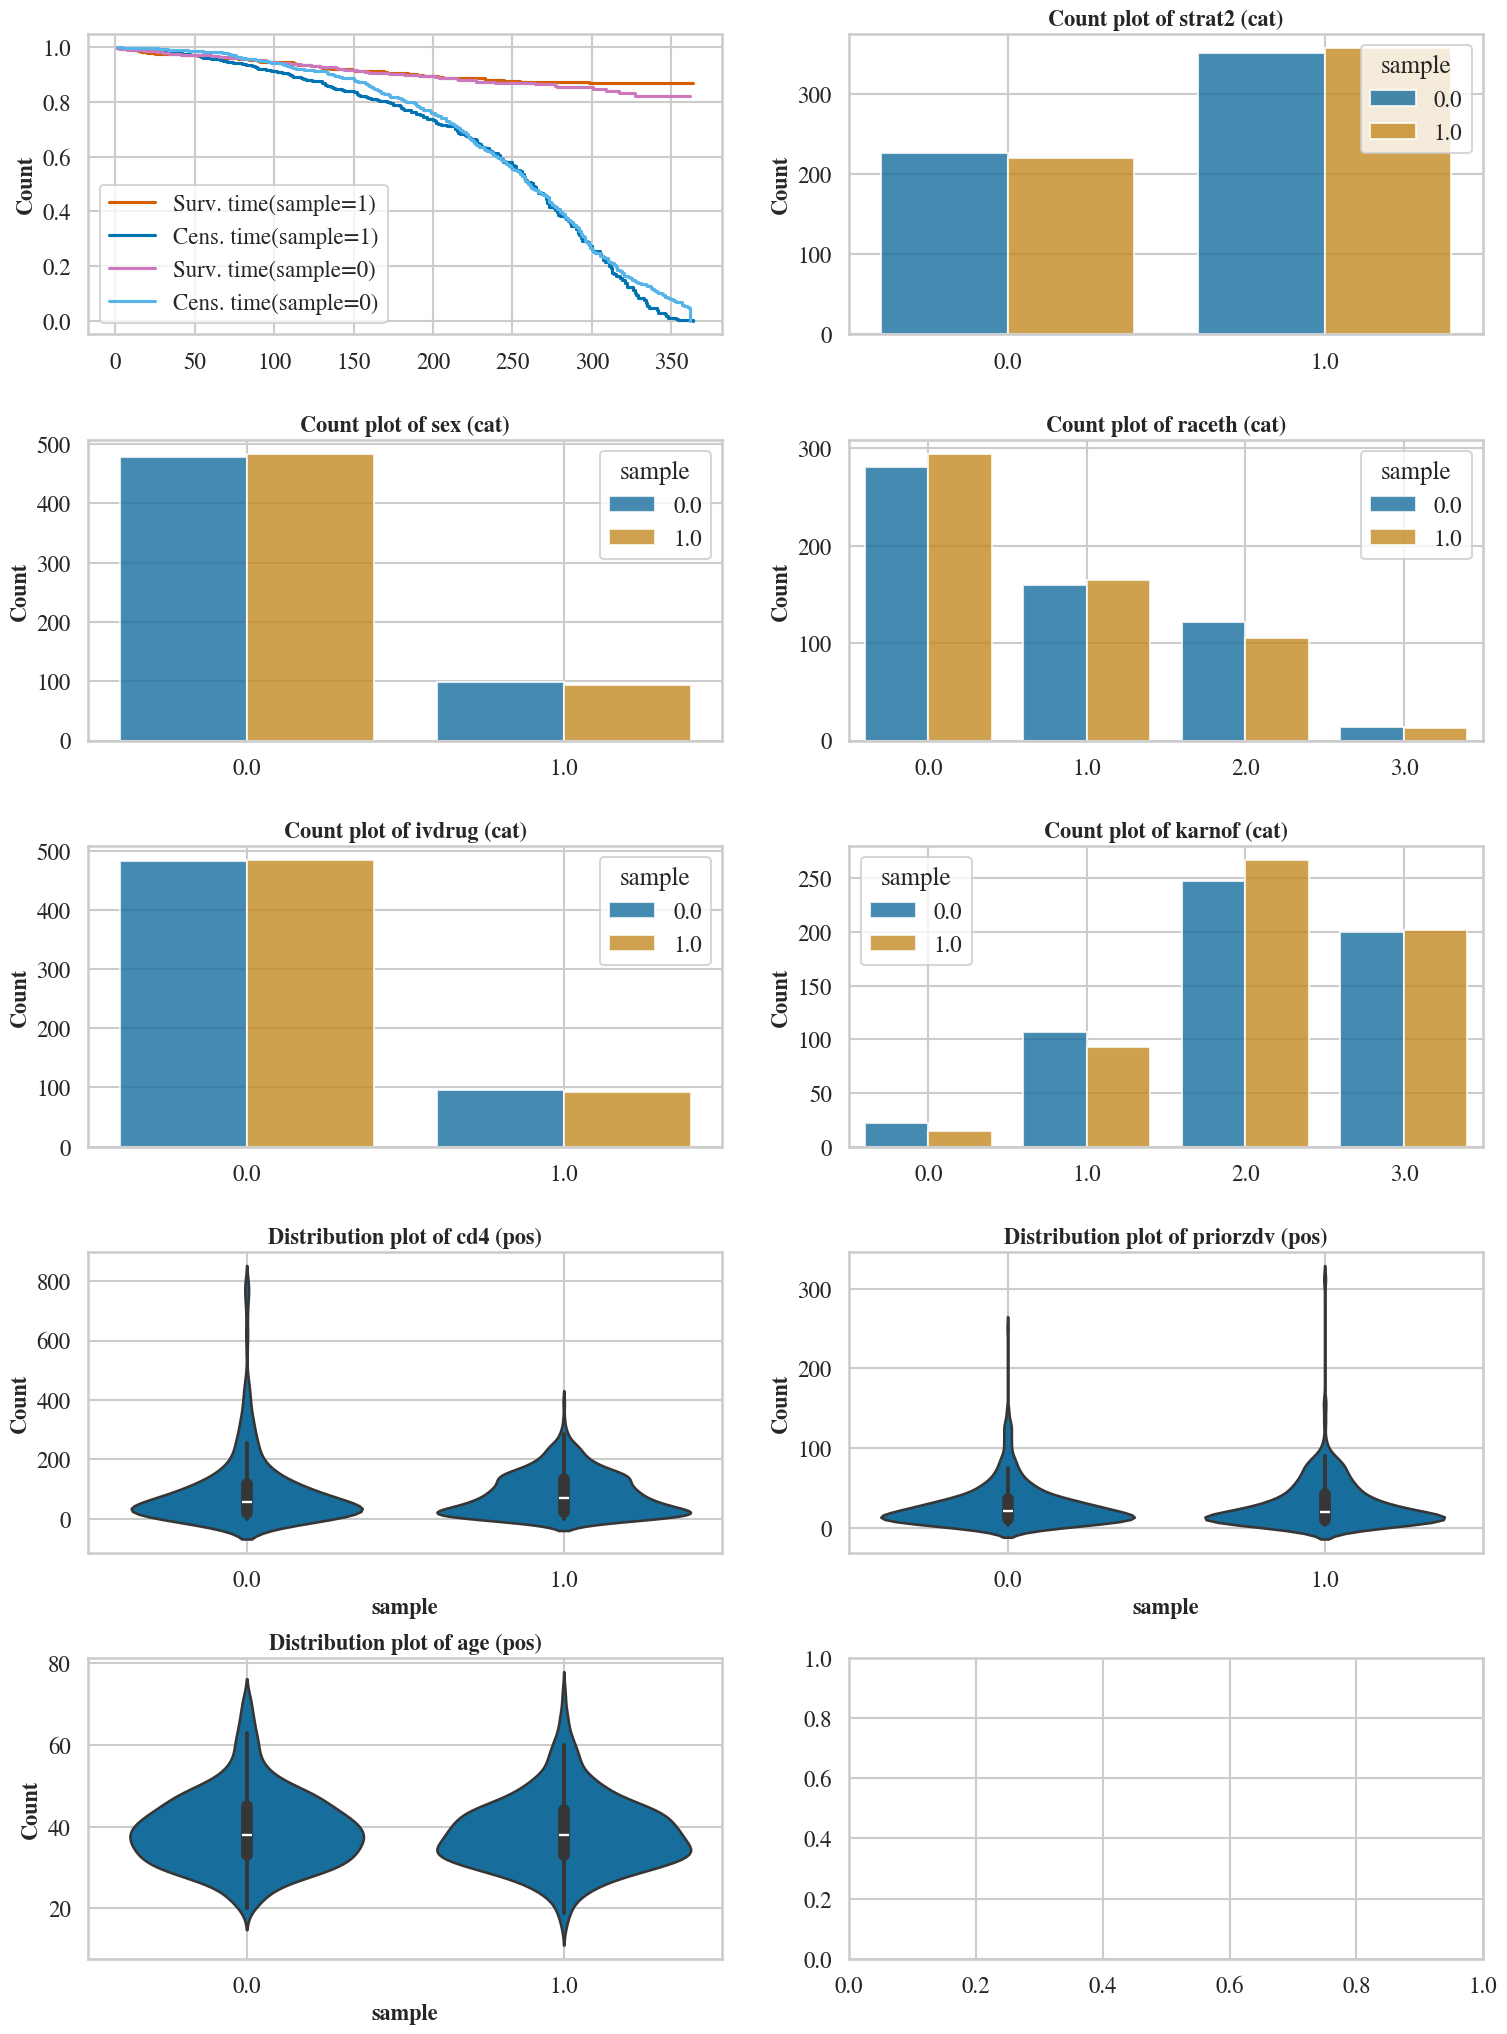

In [14]:
df_init_control_ext = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)
df_init_control_ext['sample'] = 1

sel_idx = 19
df_gen_control_ext_sel = pd.DataFrame(data_gen_control[sel_idx].numpy(), columns=control_fnames)
df_gen_control_ext_sel['sample'] = 0

feat_types_dict_ext = feat_types_dict.copy()
feat_types_dict_ext.append({'name': 'sample', 'type': 'cat', 'dim': '1', 'nclass': '2'})
df_control_sel = pd.concat([df_init_control_ext, df_gen_control_ext_sel], ignore_index=True)
visualization.plot_data(df_control_sel.to_numpy(), feat_types_dict_ext, feat_comparison_name = 'sample')

In [15]:
surv_table1, _, _, _ = tableone_tests(df_control_sel, groupby ='sample', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

table1 = TableOne(df_control_sel, categorical=categorical, continuous=continuous, groupby='sample', nonnormal=continuous, pval=True)
print(table1)

Log-rank test p-value: 0.431
                             Grouped by sample                                                                 
                                       Missing            Overall                  0                  1 P-Value
n                                                            1154                577                577        
strat2, n (%)            0.0                           446 (38.6)         226 (39.2)         220 (38.1)   0.762
                         1.0                           708 (61.4)         351 (60.8)         357 (61.9)        
sex, n (%)               0.0                           961 (83.3)         478 (82.8)         483 (83.7)   0.752
                         1.0                           193 (16.7)          99 (17.2)          94 (16.3)        
raceth, n (%)            0.0                           575 (49.8)         281 (48.7)         294 (51.0)   0.641
                         1.0                           325 (28.2)         1

### 3.2. Statistical analysis: one generated control group vs. initial treated data

In [16]:
sel_idx = 0
df_gen_control_sel = list_df_gen_control[sel_idx]
df_syn_sel = pd.concat([df_init_treated, df_gen_control_sel], ignore_index=True)

Observed control vs observed treated log-rank test p-value: 0.001
Generated control vs observed treated log-rank test p-value: 0.0


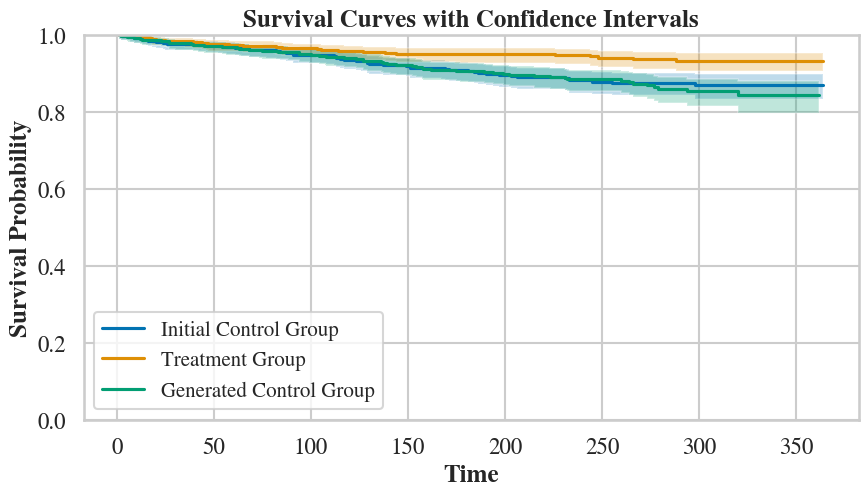

In [17]:
surv_table1, _, _, _ = tableone_tests(df_init, groupby ='treatment', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Observed control vs observed treated log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

surv_table1, _, _, _ = tableone_tests(df_syn_sel, groupby ='treatment', categorical=categorical, continuous=continuous, nonnormal=continuous)
print("Generated control vs observed treated log-rank test p-value: " + surv_table1.loc['survcens', 'P-Value'])

surv_time_control_init = df_init[df_init['treatment']==0].to_numpy()[:,0]
surv_ind_control_init = df_init[df_init['treatment']==0].to_numpy()[:,1].astype(bool)
surv_time_treated_init = df_init[df_init['treatment']==1].to_numpy()[:,0]
surv_ind_treated_init = df_init[df_init['treatment']==1].to_numpy()[:,1].astype(bool)
surv_time_control_gen = df_syn_sel[df_syn_sel['treatment']==0].to_numpy()[:,0]
surv_ind_control_gen = df_syn_sel[df_syn_sel['treatment']==0].to_numpy()[:,1].astype(bool)

uniq_time_control_init, surv_prob_control_init, conf_int_control_init = kaplan_meier_estimator(surv_ind_control_init, surv_time_control_init, conf_type="log-log")
uniq_time_treated_init, surv_prob_treated_init, conf_int_treated_init = kaplan_meier_estimator(surv_ind_treated_init, surv_time_treated_init, conf_type="log-log")
uniq_time_control_gen, surv_prob_control_gen, conf_int_control_gen = kaplan_meier_estimator(surv_ind_control_gen, surv_time_control_gen, conf_type="log-log")

plt.figure(figsize=(10, 5))
plt.step(uniq_time_control_init, surv_prob_control_init, where="post", label="Initial Control Group")
plt.fill_between(uniq_time_control_init, conf_int_control_init[0], conf_int_control_init[1], alpha=0.25, step="post")

plt.step(uniq_time_treated_init, surv_prob_treated_init, where="post", label="Treatment Group")
plt.fill_between(uniq_time_treated_init, conf_int_treated_init[0], conf_int_treated_init[1], alpha=0.25, step="post")

plt.step(uniq_time_control_gen, surv_prob_control_gen, where="post", label="Generated Control Group")
plt.fill_between(uniq_time_control_gen, conf_int_control_gen[0], conf_int_control_gen[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.legend(fontsize=15)
plt.xlabel("Time", fontweight="semibold")
plt.ylabel("Survival Probability", fontweight="semibold")
plt.title("Survival Curves with Confidence Intervals", fontweight="bold")
plt.show()

## 4. Testing

### 4.1. Univariate testing: real treated vs synthetic control

In [18]:
from metrics import log_rank, cox_estimation

data_syn = []
for i in range(n_generated_dataset):
    df_gen_control = list_df_gen_control[i]
    data_syn.append(pd.concat([df_init_treated, df_gen_control], ignore_index=True))

LR_init, LR_syn = log_rank(df_init, data_syn)
coef_init, coef_syn, cox_p_value_init, cox_p_value_syn = cox_estimation(df_init, data_syn)

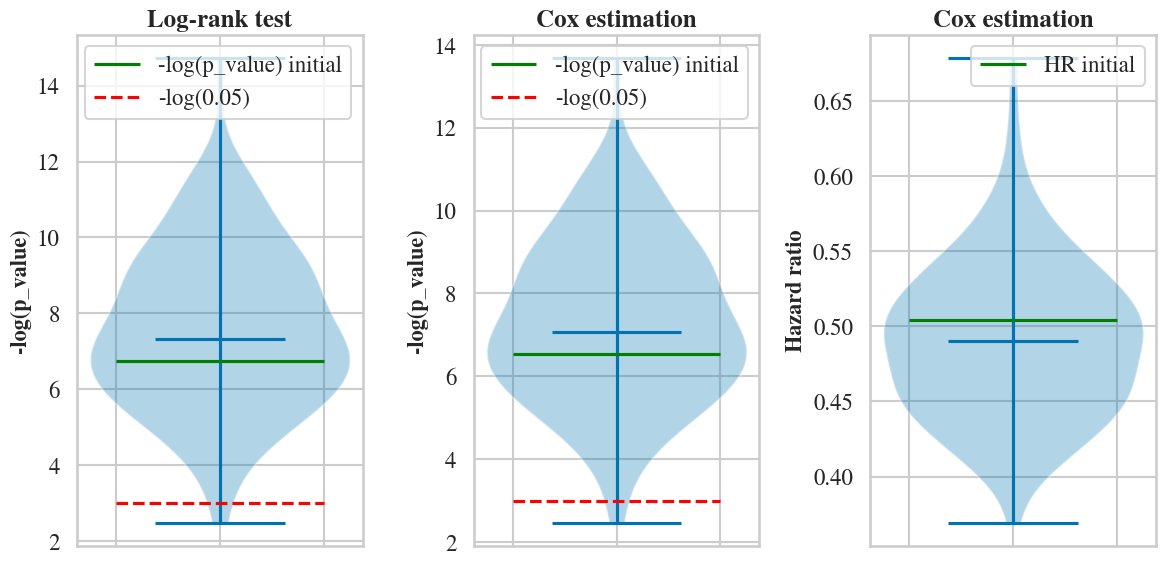

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

axs[0].violinplot(LR_syn, showmeans=False, showmedians=True)   
axs[0].hlines(LR_init, 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[0].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[0].set_xticklabels('')
axs[0].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[0].set_title('Log-rank test', fontweight="bold", size=18)
axs[0].legend(loc='upper right')

axs[1].violinplot(-np.log(cox_p_value_syn), showmeans=False, showmedians=True)
axs[1].hlines(-np.log(cox_p_value_init), 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[1].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[1].set_title('Cox estimation', fontweight="bold", size=18)
axs[1].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[1].set_xticklabels('')
axs[1].legend(loc='upper right')

axs[2].violinplot(np.exp(coef_syn), showmeans=False, showmedians=True)
axs[2].hlines(np.exp(coef_init), 0.8, 1.2, color='green', label='HR initial')
axs[2].set_title('Cox estimation', fontweight="bold", size=18)
axs[2].set_ylabel('Hazard ratio', fontweight="semibold", size=16)
axs[2].set_xticklabels('')
axs[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 4.2. Stratified testing: real treated vs synthetic control

#### 4.2.1. Categorical variable

In [20]:
from metrics import strata_log_rank, strata_cox_estimation

strata_var = categorical[0]
df_init_strata = df_init.copy(deep=True)
df_init_treated_strata = df_init_treated.copy(deep=True)

data_syn_strata = []
for i in range(n_generated_dataset):
    df_gen_control_strata = pd.DataFrame(data_gen_control[i].numpy(), columns=control_fnames)
    df_gen_control_strata['treatment'] = 0
    data_syn_strata.append(pd.concat([df_init_treated_strata, df_gen_control_strata], ignore_index=True))

strata_LR_init, strata_LR_syn = strata_log_rank(df_init_strata, data_syn_strata, strata=strata_var)
strata_coef_init, strata_coef_syn, strata_cox_p_value_init, strata_cox_p_value_syn = strata_cox_estimation(df_init_strata, data_syn_strata, strata=strata_var)

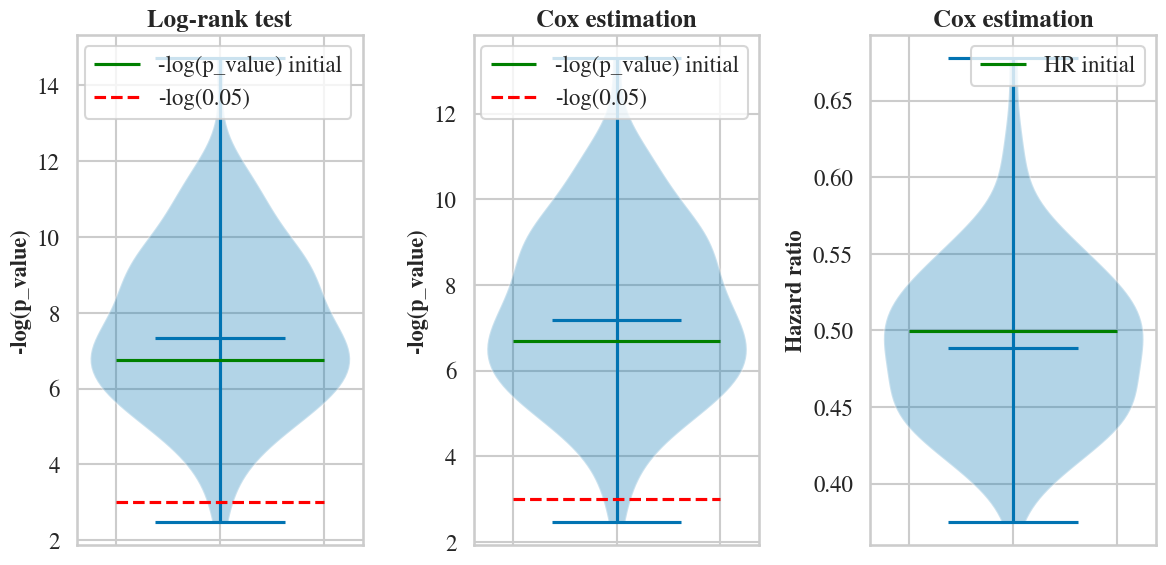

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

axs[0].violinplot(strata_LR_syn, showmeans=False, showmedians=True)   
axs[0].hlines(strata_LR_init, 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[0].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[0].set_xticklabels('')
axs[0].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[0].set_title('Log-rank test', fontweight="bold", size=18)
axs[0].legend(loc='upper right')

axs[1].violinplot(-np.log(strata_cox_p_value_syn), showmeans=False, showmedians=True)
axs[1].hlines(-np.log(strata_cox_p_value_init), 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[1].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[1].set_title('Cox estimation', fontweight="bold", size=18)
axs[1].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[1].set_xticklabels('')
axs[1].legend(loc='upper right')

axs[2].violinplot(np.exp(strata_coef_syn), showmeans=False, showmedians=True)
axs[2].hlines(np.exp(strata_coef_init), 0.8, 1.2, color='green', label='HR initial')
axs[2].set_title('Cox estimation', fontweight="bold", size=18)
axs[2].set_ylabel('Hazard ratio', fontweight="semibold", size=16)
axs[2].set_xticklabels('')
axs[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

#### 4.2.2. Continous variable

In [22]:
# Define the stratified variable
strata_var = continuous[0]
str_strata_var = 'is_low_' + strata_var
strata_var_threshold = df_init[strata_var].quantile(.4)

df_init_strata = df_init.copy(deep=True)
df_init_strata[str_strata_var] = (df_init_strata[strata_var] < strata_var_threshold).astype(int)
df_init_treated_strata = df_init_treated.copy(deep=True)
df_init_treated_strata[str_strata_var] = (df_init_treated_strata[strata_var] < strata_var_threshold).astype(int)

data_syn_strata = []
for i in range(n_generated_dataset):
    df_gen_control_strata = pd.DataFrame(data_gen_control[i].numpy(), columns=control_fnames)
    df_gen_control_strata['treatment'] = 0
    df_gen_control_strata[str_strata_var] = (df_gen_control_strata[strata_var] < strata_var_threshold).astype(int)
    data_syn_strata.append(pd.concat([df_init_treated_strata, df_gen_control_strata], ignore_index=True))

strata_LR_init, strata_LR_syn = strata_log_rank(df_init_strata, data_syn_strata, strata=str_strata_var)
strata_coef_init, strata_coef_syn, strata_cox_p_value_init, strata_cox_p_value_syn = strata_cox_estimation(df_init_strata, data_syn_strata, strata=str_strata_var)

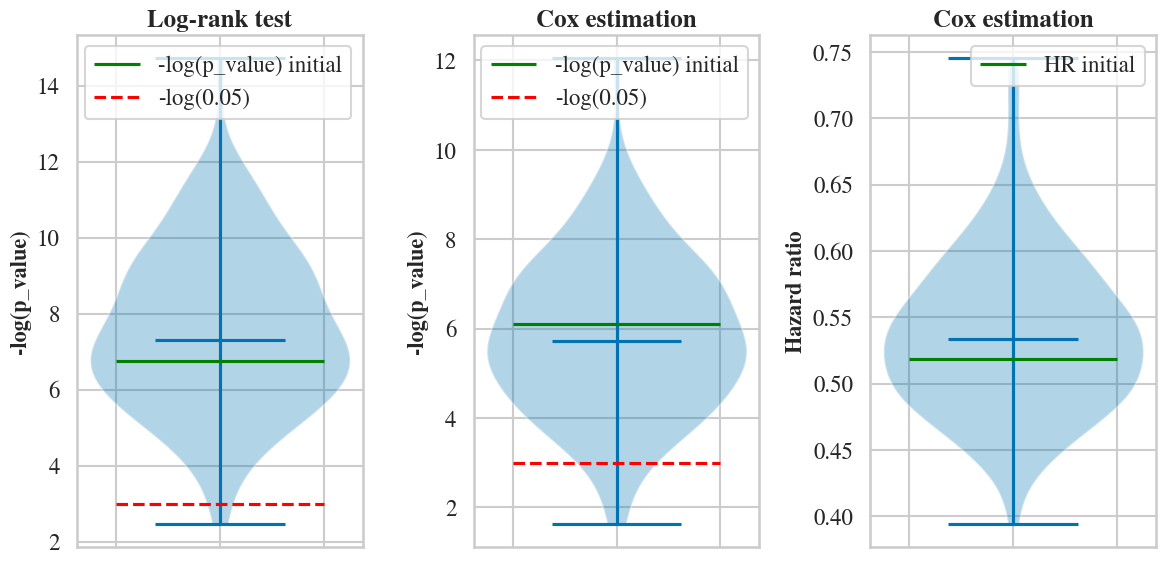

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))

axs[0].violinplot(strata_LR_syn, showmeans=False, showmedians=True)   
axs[0].hlines(strata_LR_init, 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[0].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[0].set_xticklabels('')
axs[0].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[0].set_title('Log-rank test', fontweight="bold", size=18)
axs[0].legend(loc='upper right')

axs[1].violinplot(-np.log(strata_cox_p_value_syn), showmeans=False, showmedians=True)
axs[1].hlines(-np.log(strata_cox_p_value_init), 0.8, 1.2, color='green', label='-log(p_value) initial')
axs[1].hlines(-np.log(0.05), 0.8, 1.2, color='red', linestyle='--', label='-log(0.05)')
axs[1].set_title('Cox estimation', fontweight="bold", size=18)
axs[1].set_ylabel('-log(p_value)', fontweight="semibold", size=16)
axs[1].set_xticklabels('')
axs[1].legend(loc='upper right')

axs[2].violinplot(np.exp(strata_coef_syn), showmeans=False, showmedians=True)
axs[2].hlines(np.exp(strata_coef_init), 0.8, 1.2, color='green', label='HR initial')
axs[2].set_title('Cox estimation', fontweight="bold", size=18)
axs[2].set_ylabel('Hazard ratio', fontweight="semibold", size=16)
axs[2].set_xticklabels('')
axs[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. Model evaluation

### 5.1. Metrics computed per generated dataset

In [24]:
from metrics import general_metrics_modular


simple_score_metrics = {'stats': ['jensenshannon_dist', 'survival_km_distance'],
                        'detection': ['detection_xgb'],
                        'privacy': ['k-map', 'identifiability_score']}


score_df = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), list_df_gen_control_recoded, 
                                                   'hivae', simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                    categorical=categorical, continuous=continuous,
                                                    nonnormal=continuous)

  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


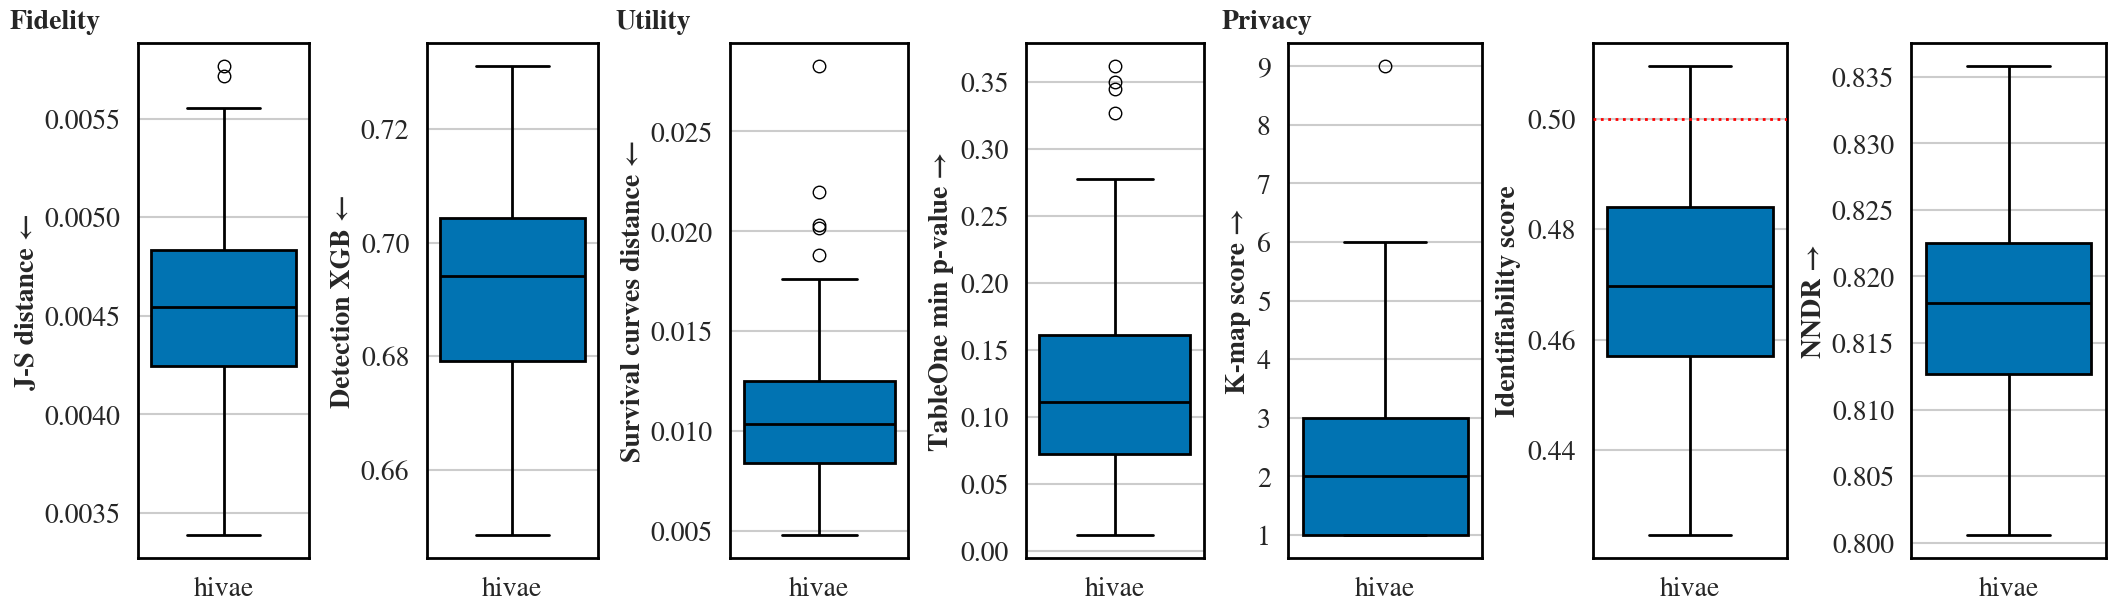

In [25]:
from visualization import visualize_grouped_perf
dict_metrics = {"Fidelity": [["J-S distance", "min"], ["Detection XGB", "min"]],
                "Utility": [["Survival curves distance", "min"], ['TableOne min p-value', 'max']],
                "Privacy": [["K-map score", "max"], ["Identifiability score", 0.5], ["NNDR", "max"]]}
visualize_grouped_perf(score_df, dict_metrics)

### 5.2. Membership Inference Attack

In [26]:
list_indexes_train = list_indexes_train = list(np.random.choice(len(df_init_control), size=int(2/3 * len(df_init_control)), replace=False))

df_init_control_train = df_init_control[df_init_control.index.isin(list_indexes_train)].reset_index(drop=True)
df_init_control_holdout = df_init_control[~df_init_control.index.isin(list_indexes_train)].reset_index(drop=True)

df_init_control_encoded_train = df_init_control_encoded[df_init_control_encoded.index.isin(list_indexes_train)].reset_index(drop=True)

In [27]:
data_gen_control_mia = surv_hivae.run(df_init_control_encoded_train,
                                      miss_mask_control[list_indexes_train], 
                                      true_miss_mask_control[list_indexes_train],
                                      feat_types_dict,
                                      n_generated_dataset,
                                      seed=1,
                                      apply_rounding=True)

list_df_gen_control_mia = []
for j in range(n_generated_dataset):
    df_gen_control_mia_j = pd.DataFrame(data_gen_control_mia[j].numpy(), columns=control_fnames)
    df_gen_control_mia_j['treatment'] = 0
    list_df_gen_control_mia.append(df_gen_control_mia_j)



Epoch: [ 0]  time: 0.0817, ELBO_train: -21.65686321, KL_z: 1.38172352, KL_s: 0.07286576, reconstruction loss: -20.20227393
Epoch: [100]  time: 8.4698, ELBO_train: -17.49581909, KL_z: 0.69264117, KL_s: 0.04573419, reconstruction loss: -16.75744373
Epoch: [200]  time: 22.8502, ELBO_train: -17.17621040, KL_z: 0.86973624, KL_s: 0.02145047, reconstruction loss: -16.28502370
Epoch: [300]  time: 37.2810, ELBO_train: -17.13088179, KL_z: 1.08910522, KL_s: 0.01481388, reconstruction loss: -16.02696269
Epoch: [400]  time: 52.9133, ELBO_train: -16.96578884, KL_z: 1.28651690, KL_s: 0.01303485, reconstruction loss: -15.66623709
Epoch: [500]  time: 66.6937, ELBO_train: -17.13312149, KL_z: 1.46490836, KL_s: 0.00911604, reconstruction loss: -15.65909709
Epoch: [600]  time: 74.5137, ELBO_train: -16.98160982, KL_z: 1.56290022, KL_s: 0.00768705, reconstruction loss: -15.41102255
Epoch: [700]  time: 81.4844, ELBO_train: -17.00708771, KL_z: 1.66319248, KL_s: 0.00759733, reconstruction loss: -15.33629789
Epo

In [28]:
from metrics import membership_inference_attack
mia_results_dict = membership_inference_attack(df_init_control_train, df_init_control_holdout, list_df_gen_control_mia, categorical=categorical_variables_control+['censor', 'treatment'], bootstrap=True, return_boot_auc=True)

In [29]:
mia_score_df = pd.DataFrame()
mia_score_df['AUC-ROC'] = mia_results_dict['boot_auc']
mia_score_df['generator'] = 'hivae'

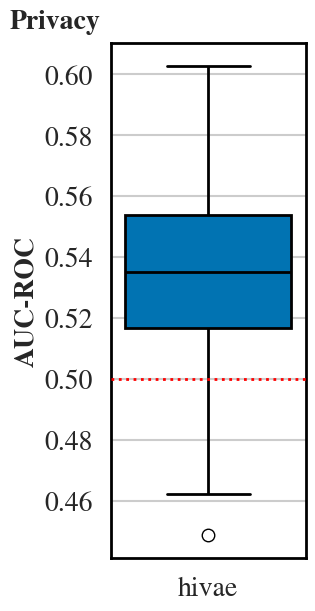

In [30]:
visualize_grouped_perf(mia_score_df, {"Privacy": [["AUC-ROC", 0.5]]})

## Bonus: Augmentation case

In [31]:
aug_frac = 1/3
n_samples_control = round(aug_frac * len(df_init_control))

In [33]:
df_init_control_aug = df_init_control.iloc[:n_samples_control]
df_init_control_encoded_aug = df_init_control_encoded.iloc[:n_samples_control]

## Note: We keep default hyperparameters. Optimal hyperparameters differ between augmentation and data sharing settings.

# In this case, to generate more rows than the ones present in the training dataframe using the posterior distribution,
# we re-sample rows with replacement.

data_gen_control_aug = surv_hivae.run(df_init_control_encoded_aug,
                                      miss_mask_control[:n_samples_control],
                                      true_miss_mask_control[:n_samples_control],
                                      feat_types_dict,
                                      n_generated_dataset,
                                      n_generated_sample=len(df_init_control),
                                      seed=1,
                                      apply_rounding=True)


Epoch: [ 0]  time: 0.0567, ELBO_train: -21.69460869, KL_z: 1.41275746, KL_s: 0.07656706, reconstruction loss: -20.20528417
Epoch: [100]  time: 3.4258, ELBO_train: -17.50795460, KL_z: 0.58279210, KL_s: 0.02974205, reconstruction loss: -16.89542044
Epoch: [200]  time: 6.7201, ELBO_train: -17.17077160, KL_z: 0.76383594, KL_s: 0.01653378, reconstruction loss: -16.39040189
Epoch: [300]  time: 9.7400, ELBO_train: -17.30381870, KL_z: 0.86597717, KL_s: 0.01275077, reconstruction loss: -16.42509076
Epoch: [400]  time: 13.5162, ELBO_train: -17.37051392, KL_z: 0.94527265, KL_s: 0.01076042, reconstruction loss: -16.41448084
Epoch: [500]  time: 17.4712, ELBO_train: -16.96736526, KL_z: 1.06081587, KL_s: 0.01028662, reconstruction loss: -15.89626278
Epoch: [600]  time: 20.8303, ELBO_train: -17.04398346, KL_z: 1.18347555, KL_s: 0.00869488, reconstruction loss: -15.85181302
Epoch: [700]  time: 23.8531, ELBO_train: -16.72837448, KL_z: 1.30028152, KL_s: 0.00756500, reconstruction loss: -15.42052796
Early

In [34]:
list_df_gen_control_aug = []
for j in range(n_generated_dataset):
    df_gen_control_aug_j = pd.DataFrame(data_gen_control_aug[j].numpy(), columns=control_fnames)
    df_gen_control_aug_j['treatment'] = 0
    list_df_gen_control_aug.append(df_gen_control_aug_j)

In [35]:
#For export, recode the categorical variables to their original levels
list_df_gen_control_aug_recoded = [
    data_processing.decode_categoricals(df, dict_cat_map_control)
    for df in list_df_gen_control_aug]

In [36]:
score_df_aug = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), list_df_gen_control_aug_recoded, 
                                                   "hivae_aug", simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
                                                    categorical=categorical, continuous=continuous,
                                                    nonnormal=continuous)

In [37]:
score_df_complete = pd.concat([score_df, score_df_aug], ignore_index=True)

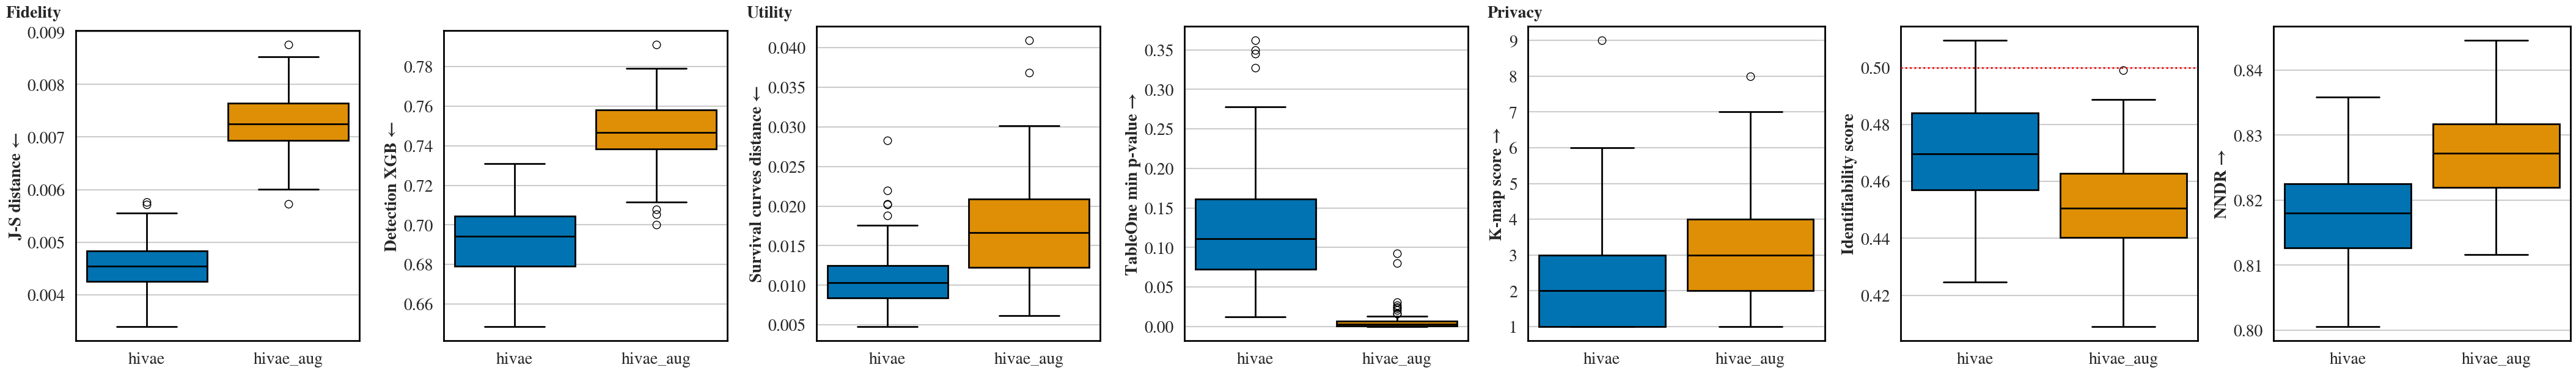

In [38]:
visualize_grouped_perf(score_df_complete, dict_metrics)